# Capítulo 15 — Perigos de Tempestades: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | granizo: que updraft sustenta que pedra? | NumPy |
| 2 | downburst: DCAPE e a rajada no chão | `solve_ivp` |
| 3 | relâmpago: o capacitor da tempestade | `solve_ivp` |
| 4 | tornado: vórtice de Rankine e a queda de pressão | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap15_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Cp, Lv = 9.8, 1004.0, 2.5e6
rho_ar, rho_gelo = 1.0, 900.0

## Caso 1 — Granizo: a balança updraft × queda

Uma pedra de granizo só cresce enquanto o updraft a sustenta. Igualando peso e arrasto:
$$w_T = \sqrt{\frac{4\,g\,\rho_{gelo}\,D}{3\,C_d\,\rho_{ar}}}\;\propto\;\sqrt{D}.$$
Updraft de 40 m/s sustenta pedras de ~5 cm — por isso granizo grande denuncia supercélula (Cap. 14).

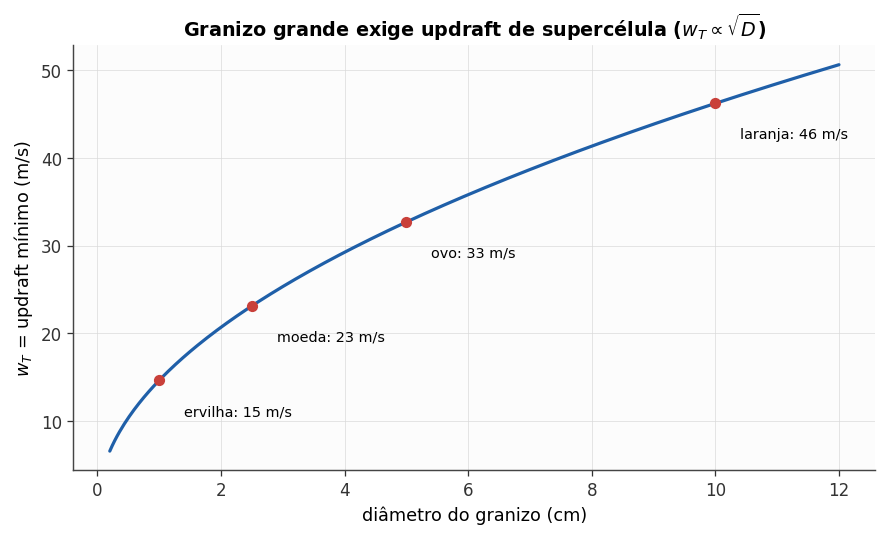

pedra de 5 cm: updraft ≥ 32 m/s — só o CAPE alto + organização do Cap. 14;
as trajetorias em espiral pelo updraft explicam as camadas de cebola da pedra.


In [2]:
Cd = 0.55
D = np.linspace(0.002, 0.12, 300)             # 2 mm a 12 cm
wT = np.sqrt(4*g*rho_gelo*D/(3*Cd*rho_ar))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(D*100, wT, color=CORES['azul'], lw=2)
for d_cm, nome in [(1, 'ervilha'), (2.5, 'moeda'), (5, 'ovo'), (10, 'laranja')]:
    w_n = np.sqrt(4*g*rho_gelo*(d_cm/100)/(3*Cd*rho_ar))
    ax.plot(d_cm, w_n, 'o', color=CORES['vermelho'], ms=6)
    ax.annotate(f'{nome}: {w_n:.0f} m/s'.replace('.', ','), xy=(d_cm, w_n),
                xytext=(d_cm + 0.4, w_n - 4), fontsize=9)
ax.set(xlabel='diâmetro do granizo (cm)', ylabel='$w_T$ = updraft mínimo (m/s)',
       title='Granizo grande exige updraft de supercélula ($w_T \\propto \\sqrt{D}$)')
plt.show()
print('pedra de 5 cm: updraft ≥ 32 m/s — só o CAPE alto + organização do Cap. 14;')
print('as trajetorias em espiral pelo updraft explicam as camadas de cebola da pedra.')

## Caso 2 — Downburst: o CAPE de cabeça para baixo

Chuva evaporando numa camada sub-nuvem seca gera empuxo **negativo**. O análogo descendente do CAPE é o **DCAPE**; a rajada no chão:
$$w_{down} \simeq \sqrt{2\,\mathrm{DCAPE}}\quad\to\quad\text{rajada horizontal ao espalhar}.$$

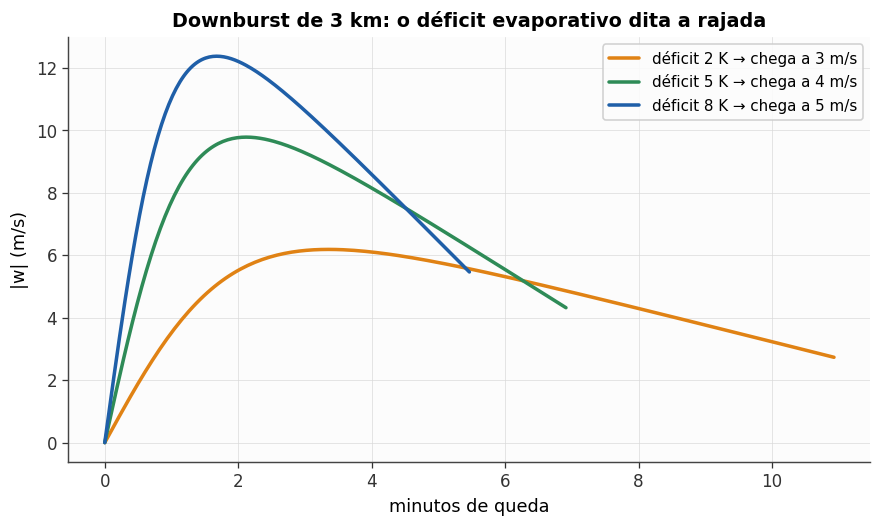

estimativa DCAPE (déficit 5 K): 243 J/kg -> w = 22 m/s;
ao tocar o solo o jato vira rajada horizontal (perigo classico de aviacao —
e a origem das frentes de rajada do Cap. 14).


In [3]:
theta0 = 302.0
z_base = 3000.0

def downburst(deficit_K, arrasto=1.2e-3):
    def rhs(t, y):
        z, w = y
        frac = np.clip(z/z_base, 0, 1)          # déficit mantido pela evaporação
        B = -g*deficit_K*frac/theta0
        return [w, B - arrasto*abs(w)*w]
    def chao(t, y):
        return y[0]
    chao.terminal, chao.direction = True, -1
    s = solve_ivp(rhs, [0, 3000], [z_base, 0.0], events=chao,
                  dense_output=True, rtol=1e-8)
    return s

fig, ax = plt.subplots(figsize=(9, 4.8))
for dK, cor in [(2, CORES['laranja']), (5, CORES['verde']), (8, CORES['azul'])]:
    s = downburst(dK)
    tt = np.linspace(0, s.t[-1], 200)
    zz, ww = s.sol(tt)
    ax.plot(tt/60, np.abs(ww), color=cor,
            label=f'déficit {dK} K → chega a {abs(ww[-1]):.0f} m/s'.replace('.', ','))
ax.set(xlabel='minutos de queda', ylabel='|w| (m/s)',
       title='Downburst de 3 km: o déficit evaporativo dita a rajada')
ax.legend()
plt.show()
dcape = g*5*0.5*z_base/theta0                  # déficit médio ~ metade
print(f'estimativa DCAPE (déficit 5 K): {dcape:.0f} J/kg -> w = {np.sqrt(2*dcape):.0f} m/s;')
print('ao tocar o solo o jato vira rajada horizontal (perigo classico de aviacao —')
print('e a origem das frentes de rajada do Cap. 14).')

## Caso 3 — O capacitor da tempestade

Colisões graupel–cristal separam carga (positiva em cima, negativa embaixo). Modelamos a nuvem como capacitor carregado por corrente $I_c$ e descarregado quando o campo atinge a ruptura:
$$\frac{dQ}{dt} = I_c - \frac{Q}{RC},\qquad E = \frac{Q}{C\,d}.$$

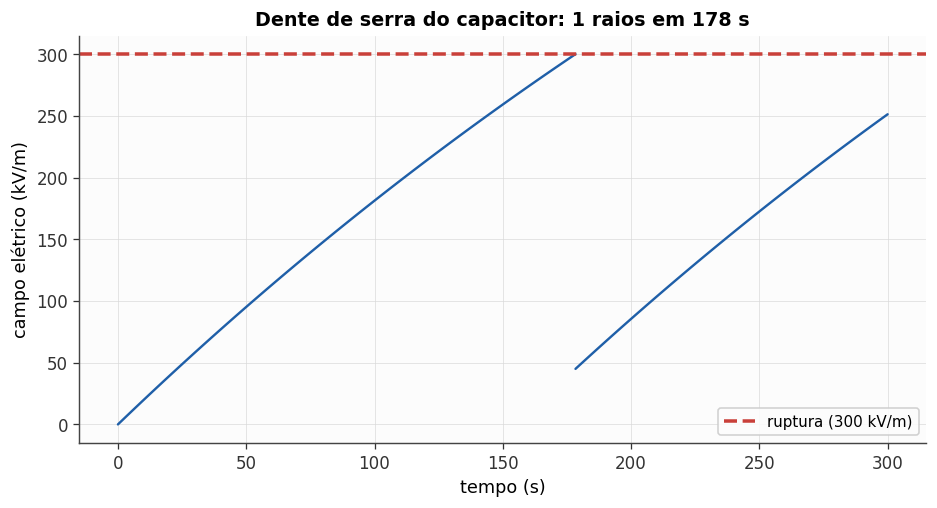

taxa ~ 0.3 raios/min — tempestade eletricamente ativa;
energia por raio ~ Q*V/2 = 112.5 GJ (ordem certa: ~1-10 GJ).


In [4]:
I_c = 1.0                                     # A (corrente de carga da nuvem)
C_nuvem = 0.1e-6                              # F (nuvem-solo, ordem de grandeza)
R_fuga = 5e9                                  # Ohm (ar limpo conduz um pouco)
E_rup = 3e5                                   # V/m com gotas (300 kV/m; ar seco: 3 MV/m)
d = 5000.0                                    # m

Q_rup = E_rup*d*C_nuvem
def carga(t, Q):
    return I_c - Q[0]/(R_fuga*C_nuvem)

raios, t_now, Q0, historia = 0, 0.0, 0.0, []
while t_now < 300 and raios < 12:
    def rompe(t, Q):
        return Q[0] - Q_rup
    rompe.terminal, rompe.direction = True, 1
    s = solve_ivp(carga, [t_now, 300], [Q0], events=rompe, dense_output=True,
                  max_step=0.5)
    tt = np.linspace(t_now, s.t[-1], 60)
    historia.append((tt, s.sol(tt)[0]))
    if s.t_events[0].size:
        raios += 1; t_now = s.t_events[0][0]; Q0 = 0.15*Q_rup   # descarga ~85%
    else:
        break

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for tt, QQ in historia:
    ax.plot(tt, QQ/C_nuvem/d/1e3, color=CORES['azul'], lw=1.5)
ax.axhline(E_rup/1e3, color=CORES['vermelho'], ls='--', label='ruptura (300 kV/m)')
ax.set(xlabel='tempo (s)', ylabel='campo elétrico (kV/m)',
       title=f'Dente de serra do capacitor: {raios} raios em {t_now:.0f} s')
ax.legend()
plt.show()
print(f'taxa ~ {raios/(t_now/60):.1f} raios/min — tempestade eletricamente ativa;')
print(f'energia por raio ~ Q*V/2 = {Q_rup*E_rup*d/2/1e9:.1f} GJ (ordem certa: ~1-10 GJ).')

## Caso 4 — Tornado: vórtice de Rankine

Núcleo em rotação sólida ($v \propto r$) + exterior potencial ($v \propto 1/r$). No equilíbrio **ciclostrófico** (Cap. 10, sem Coriolis!):
$$\frac{dP}{dr} = \frac{\rho\,v^2}{r}\quad\Rightarrow\quad \Delta P_{centro} = \rho\,v_{max}^2.$$

EF1: dP(centro) =  15.9 hPa  (teoria rho*v² =  16.0 hPa)
EF3: dP(centro) =  48.8 hPa  (teoria rho*v² =  49.0 hPa)
EF5: dP(centro) = 120.4 hPa  (teoria rho*v² = 121.0 hPa)


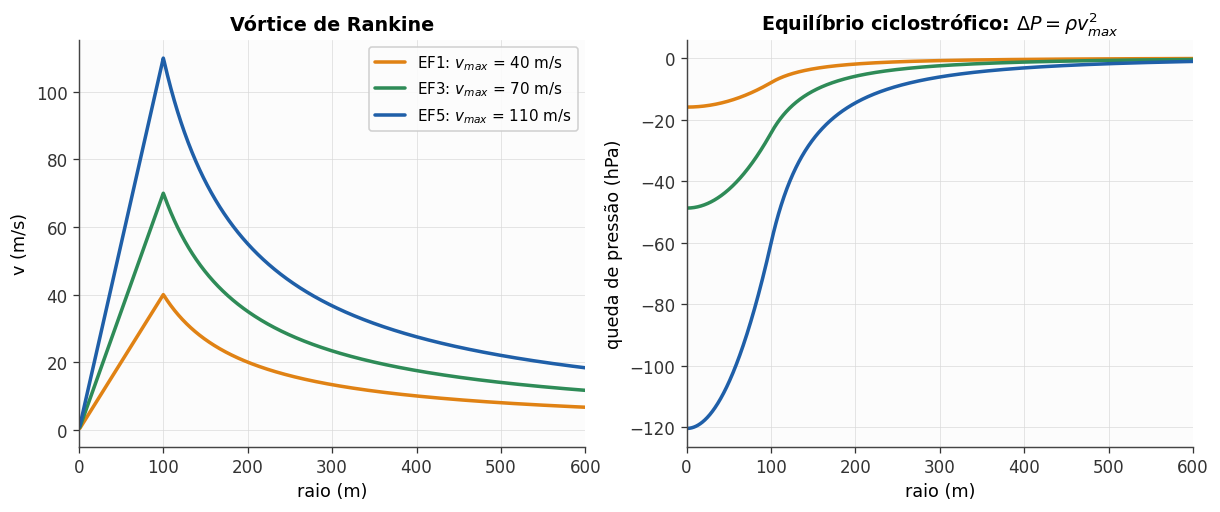


EF5: ~120 hPa de queda em 100 m — o gradiente que nenhuma escala
sinotica alcanca; e a sucção + vento dinamico que destroem estruturas (T5).


In [5]:
rho = 1.0
R0 = 100.0                                     # raio do núcleo (m)
r = np.linspace(1, 1000, 2000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for vmax, cor, ef in [(40, CORES['laranja'], 'EF1'), (70, CORES['verde'], 'EF3'),
                       (110, CORES['azul'], 'EF5')]:
    v = np.where(r <= R0, vmax*r/R0, vmax*R0/r)
    # integração ciclostrófica de fora para dentro:
    dP = np.cumsum((rho*v**2/r)[::-1]*np.gradient(r)[::-1])[::-1]
    ax1.plot(r, v, color=cor, label=f'{ef}: $v_{{max}}$ = {vmax} m/s')
    ax2.plot(r, -dP/100, color=cor)
    print(f'{ef}: dP(centro) = {dP[0]/100:5.1f} hPa  (teoria rho*v² = {rho*vmax**2/100:5.1f} hPa)')
ax1.set(xlabel='raio (m)', ylabel='v (m/s)', title='Vórtice de Rankine', xlim=(0, 600))
ax1.legend()
ax2.set(xlabel='raio (m)', ylabel='queda de pressão (hPa)',
        title='Equilíbrio ciclostrófico: $\\Delta P = \\rho v_{max}^2$', xlim=(0, 600))
plt.show()
print('\nEF5: ~120 hPa de queda em 100 m — o gradiente que nenhuma escala')
print('sinotica alcanca; e a sucção + vento dinamico que destroem estruturas (T5).')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap15_solucoes.ipynb`**.

**N1** — Derretimento na queda: uma pedra de diâmetro $D_0$ cai do nível de congelamento $z_{cong}$ derretendo a uma taxa proporcional à área e ao excesso térmico do ar. Integre $D(z)$ e ache o $D_0$ mínimo que chega ao chão para $z_{cong}$ = 3, 4 e 5 km.

**N2** — No Caso 2, faça o déficit evaporativo depender da UR da camada sub-nuvem (déficit máx. quando UR = 30%, zero quando UR = 100%) e trace a rajada final contra a UR; por que downbursts secos são traiçoeiros?

**N3** — No capacitor do Caso 3, varra a corrente de carga $I_c$ (proxy do updraft, Cap. 14) e trace a taxa de raios; compare com a observação de que a taxa de relâmpagos cresce ~$w^6$ da tempestade.

**N4** — Adicione ao vórtice de Rankine uma translação de 15 m/s e mapeie o vento total; de que lado do tornado (no HS) fica a pista de destruição mais larga?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*